In [1]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.visualization import plot_histogram
from qiskit.result import marginal_counts

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 43.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 77.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 87.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=5278a3c51ab6099c15ce70416a6fee2cea2287fde9044b5d4197c44180300587
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


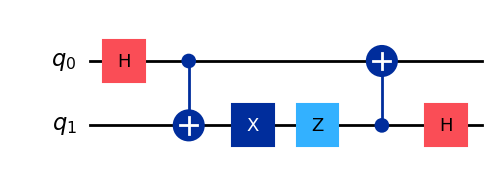

In [2]:
# Superdense coding

# The classical 2-bit value is encoded by applying X and/or Z gates

sdc = QuantumCircuit(2)

# qubits 0 and 1 are the shared entangled state
# Alice has qubit 1, Bob has qubit 0

# Entangle qubits 0 and 1
sdc.h(0)
sdc.cx(0,1)

# Encoding by Alice, working on qubit 1
# For each of 00, 01, 10, 11, there is a block of code that can be commented or uncommented.

# For 00, do nothing

# For 01, apply X to qubit 1
#sdc.x(1)

# For 10, apply Z to qubit 1
#sdc.z(1)

# For 11, apply X then Z to qubit 1
sdc.x(1)
sdc.z(1)

# Decoding by Bob, working on qubits 0 and 1

sdc.cx(1,0)
sdc.h(1)

sdc.draw("mpl")

In [3]:
state = Statevector.from_int(0, 4)  # 4 basis states on 2 qubits

# Apply the circuit to the state
state = state.evolve(sdc)

# Display using latex.
# Omit "latex" to get a numerical (not algebraic) view of the state vector.
state.draw("latex")

<IPython.core.display.Latex object>

Encoded message received: {'11': 1024}


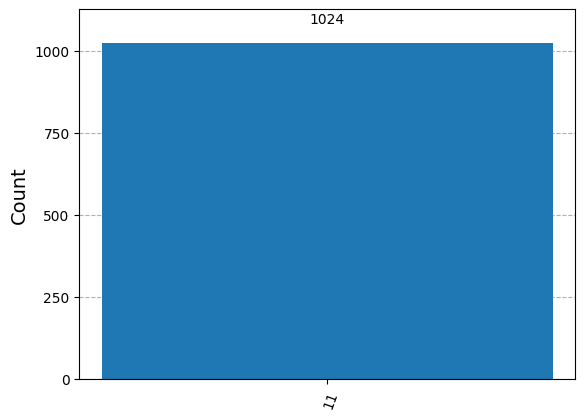

In [4]:
# EXERCISE

# Instead of calculating the state and displaying it, try simulating the circuit
# in a similar way to previous exercises. You will need to add some measurements
# so that you can check that the measurement statistics match the value that Alice
# encoded.

# 1. Add measurement gates to the circuit
# This measures both qubits and stores them in classical bits 0 and 1
sdc.measure_all()

# 2. Setup the simulator
backend = BasicSimulator()

# 3. Transpile and run the circuit
compiled = transpile(sdc, backend)
job_sim = backend.run(compiled, shots = 1024)
result_sim = job_sim.result()

# 4. Get the results and plot
counts = result_sim.get_counts(compiled)
print(f"Encoded message received: {counts}")
plot_histogram(counts)

Bob recovered the message: {'11': 6, '01': 2, '00': 5, '10': 1011}


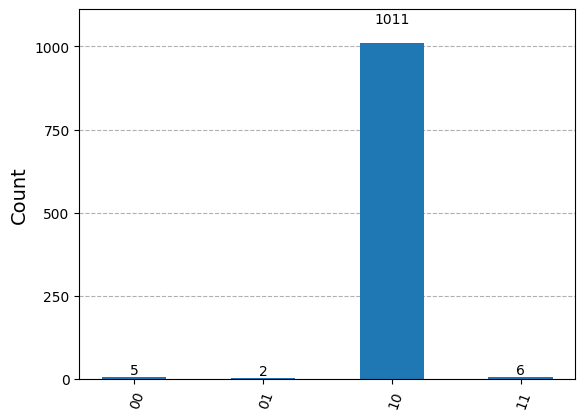

In [5]:
# EXERCISE

# A better implementation of superdense coding uses two classical bits as inputs,
# and the conditional operators that we saw in Lab-2B. Encoding the two-bit
# classical value is similar to the last stage of teleportation, where the measurement
# results are used to adjust Bob's qubit.

# Implement superdense coding this way.

# Create a circuit with 2 qubits and 2 classical bits
sdc_dynamic = QuantumCircuit(2,2)

# Preparation
# To send '01', uncomment x(0). To send '10', uncomment x(1).
# To send '11', uncomment both.
sdc_dynamic.x(0)
sdc_dynamic.x(1)
sdc_dynamic.barrier()

# 1. Create the shared Bell Pair
sdc_dynamic.h(0)
sdc_dynamic.cx(0,1)
sdc_dynamic.barrier()

# 2. Alice's Conditional Encoding
# Alice applies gates to qubit 1 based on the classical bits
with sdc_dynamic.if_test((1, 0)): # If classical bit 0 is 1
    sdc_dynamic.x(1)
with sdc_dynamic.if_test((1, 1)): # If classical bit 1 is 1
    sdc_dynamic.z(1)
sdc_dynamic.barrier()

# 3. Bob's Decoding
sdc_dynamic.cx(1,0)
sdc_dynamic.h(1)

# 4. Measurement
sdc_dynamic.measure([0,1], [0,1])

# Simulation
backend = GenericBackendV2(num_qubits=2, control_flow=True)
compiled = transpile(sdc_dynamic, backend)
job = backend.run(compiled, shots=1024)
counts = job.result().get_counts()

print(f"Bob recovered the message: {counts}")
plot_histogram(counts)